Wiener Process and Geometric Brownian Motion

This code is an exploration of Geometric Brownian Motion (GBM) and the Weiner Process. I will be using the Wiener process to simulate "noise" and GBM to translate said random noise in a realistic stock price path

The Wiener process is defined by 4 properties:
- The model starts at W(0)
- For any sequence of time, the increments (or time periods) are independent
- Increments are normally distributed with variance equal to the length of time variable
- W(t) is continuous but not differentiable

Geometric Brownian Motion (GBM) is used here over Arithmetic Brownian Motion (ABM) as it satisfies some key constraints:
- Values stay positive. In Arithmetic Brownian Motion, values can be negative which does not reflect real stock prices
- Values have an upward drift, further mirroring real life stock prices
- Values exhibit randomness proportional to the current price so changes are relative to the previous price, eliminating larger stock prices from dominating the model

In [1]:
# First Import Necessary Libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Set the parameters for the Wiener Process
S0 = 100 # Starting stock price
mu = 0.08 # Drift (average expected annual return)
sigma = 0.2 # Volatility (standard deviation of returns)
T = 1.0 # Time Horizon in Years
N = 252 # Number of Trading Days
num_paths = 5 # Number of Paths to Simulate

dt = T / N # dt is out time step size, aka our increments
t = np.linspace(0, T, N) # t is an array of time points from 0 to 1, normally distributed around 0 with a standard deviation of 1

Our next step is to generate our Wiener Process increments (dw)
dw = epsilon * sqrt(dt) where epsilon follows t, our normal distribution around 0 with a standard deviation of 1

In [3]:
epsilon = np.random.normal(0, 1, (num_paths, N))
dW = epsilon * np.sqrt(dt)

Finally, we compute the Cumulative Wiener Process (W(t)), the sum of increments from t = 0

In [4]:
W = np.cumsum(dW, axis=1)

We now pull in our GBM model using the closed form solution: the average trajectory a stock would follow without randomness.
Our diffusion_term is significant as it models our Wiener Process scaled by volatility.

In [5]:
drift_term = (mu - 0.5 * sigma**2) * t
diffusion_term = sigma * W
S = S0 * np.exp(drift_term * diffusion_term)

Lets plot our simulations to see how these terms can differ as more simulations are done.

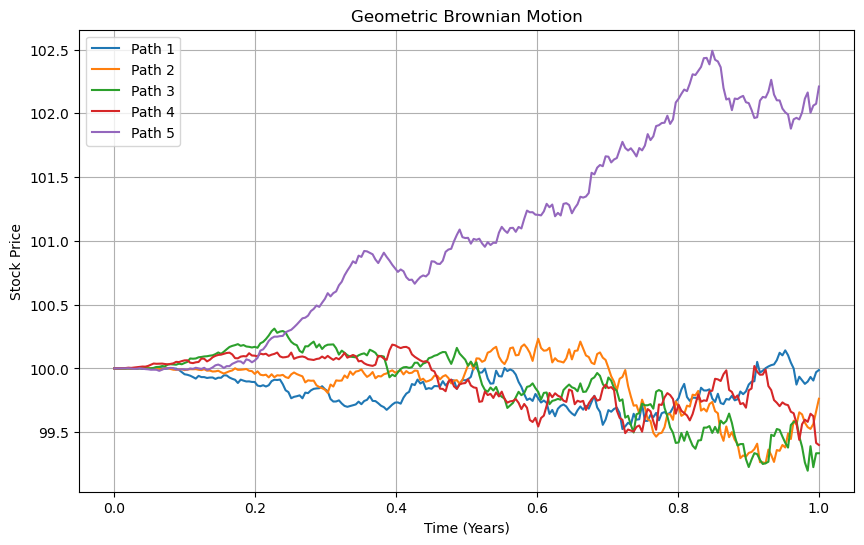

In [8]:
# Set the size of the chart and chart the simulations
plt.figure(figsize=(10,6))
for i in range(num_paths):
    plt.plot(t, S[i], label=f"Path {i+1}")

# Chart Labels 
plt.title("Geometric Brownian Motion")
plt.xlabel("Time (Years)")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

In the chart above, we can see how, over time, stock prices can change pretty wildly over time. If you increase your time horizon, you can see that the variance increases linearly as time goes on. Running more simulations can help improve the stability of statistical estimates. People that regularly use these models often perform hundreds, if not thousands of paths to try and understand where the true value lies

Creating this Notebook has helped me understand the importance of the Wiener Process as a mathematical foundation for modeling randomness over time. Geometric Brownian Motion extends these ideas to systems that evolve proportionally and remain positive, making it especially useful for modeling prices, growth processes, and uncertainty that is often seen in the stock market.